# Generate 2D example images for Nikon data

## What this notebook does:
1. Loads a plate layout CSV with experimental conditions
2. Matches it to Nikon image metadata
3. Selects a specific field from each experimental condition
4. Calculates intensity rescaling limits based on percentiles per group to achieve consistent intensities across different samples stained in the same way.
5. Renames images based on the fields used in the metadata table
6. Saves rescaled images for specified channels
7. Optionally creates segmentation overlays (if you have already done a segmentation)

## Before you start:
- Prepare your plate layout CSV file. You will need a column with well names and additional columns with information about the treatments or staining used.
- Decide which conditions/groups need to have the same rescaling limits applied
- Compute illumination correction statistics (optional)
- Perform segmentation (optional)

## Import Libraries

In [1]:
import warnings
from pathlib import Path

import mahotas as mh

import matplotlib
import matplotlib.pyplot as plt

import numpy as np
import pandas as pd
from aicsimageio import AICSImage, readers
from PIL import Image

from tqdm.auto import tqdm

try:
    from blimp.preprocessing.illumination_correction import IlluminationCorrection

    ILLUM_CORRECTION_AVAILABLE = True
except ImportError:
    ILLUM_CORRECTION_AVAILABLE = False
    warnings.warn(
        "blimp package not found. Illumination correction will not be available."
    )

09-Jun-26 14:43:36 - bfio.backends - WARNING  - Java backend is not available. This could be due to a missing dependency (jpype).
/srv/scratch/z3532965/anaconda3/envs/berrylab-py310/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---
# Configuration Section
**Edit the parameters below to match your experiment**

## File paths

Set the paths to your data

In [2]:
plate_layout_file = "/srv/scratch/z3532965/src/blana/Alex/260522_mACPOLR2A_Kinetic_pSer2/260522_mACPOLR2A_Kinetic_pSer2.csv"

image_dir = "/srv/scratch/berrylab/z3536241/NikonSpinningDisk/260522_mACPOLR2A_Kinetic_pSer2/20260526_181658_086/OME-TIFF-MIP"

# segmentation_dir = None
segmentation_dir = "/srv/scratch/berrylab/z3536241/NikonSpinningDisk/260522_mACPOLR2A_Kinetic_pSer2/20260526_181658_086/SEGMENTATION/"

# illumination_correction_file = None
illumination_correction_file = "/srv/scratch/berrylab/z3536241/NikonSpinningDisk/260518_mAC_mACmCh_TotalPolII/20260524_154125_815/ILLCORR/ILLCORR_20x_647_488_561_405.pkl"

output_dir = "/srv/scratch/berrylab/z3532965/NikonSpinningDisk/260522_mACPOLR2A_Kinetic_pSer2/20260526_181658_086/EXAMPLES"

# Output organisation structure
# "channel": Organise by channel (Channel_1_DAPI/, Channel_2_GFP/, etc.)
# "condition": Organise by condition (A01_condition1/, A02_condition2/, etc.)
folder_structure = "channel"
# folder_structure = "condition"

## Load and Preview Data

Load plate layout and image metadata files. These will be used throughout the notebook.

In [3]:
# Load plate layout
plate_layout = None
if Path(plate_layout_file):
    plate_layout = pd.read_csv(plate_layout_file, dtype=str)
    print(f"✓ Plate layout: {len(plate_layout)} rows\n")

    for col in plate_layout.columns:
        unique_values = plate_layout[col].unique()
        n_unique = len(unique_values)

        if n_unique <= 8 and all(len(str(v)) <= 20 for v in unique_values):
            print(f"  {col}: {list(unique_values)}")
        else:
            print(f"  {col}: {n_unique} unique values")
else:
    print(f"⚠ Plate layout file not found: {plate_layout_file}\n")

# Load image metadata
image_metadata = None
if Path(image_dir):
    image_metadata_files = list(Path(image_dir).glob("*.csv"))

    if image_metadata_files:
        image_metadata = pd.concat(
            (pd.read_csv(f, dtype=str) for f in image_metadata_files), ignore_index=True
        )
        print(
            f"✓ Image metadata: {len(image_metadata)} rows from {len(image_metadata_files)} file(s)\n"
        )

        for col in image_metadata.columns:
            unique_values = image_metadata[col].unique()
            n_unique = len(unique_values)

            if n_unique <= 8 and all(len(str(v)) <= 20 for v in unique_values):
                print(f"  {col}: {list(unique_values)}")
            else:
                print(f"  {col}: {n_unique} unique values")
    else:
        print(f"⚠ No CSV files found in: {image_dir}")
else:
    print(f"⚠ Image directory not found: {image_dir}")

✓ Plate layout: 240 rows

  WELL: 240 unique values
  CELL: 2 unique values
  DRUG: ['Vehicle', '5PhIAA']
  DRUG_CONCENTRATION: ['0', '10', '100', '1000', '10000']
  TIME_MINUTES: ['480', '60', '120', '240']
  PRIMARY: ['pSer2 Pol II (3E10)', 'Total Pol II (F12)', 'No primary']
  SECONDARY: 2 unique values
⚠ No CSV files found in: /srv/scratch/berrylab/z3536241/NikonSpinningDisk/260522_mACPOLR2A_Kinetic_pSer2/20260526_181658_086/OME-TIFF-MIP


## Column mapping

Specify column names. For Nikon data, you'll only have to edit ``plate_layout_well_column`` to whatever name you have used in your layout file

In [4]:
# Column name in plate layout CSV that contains well identifiers (e.g., "WellName", "well_name")
plate_layout_well_column = "WELL"

# Column name in image metadata CSV that contains the image filename
image_metadata_filename_column = "filename_ome_tiff"

# Column name in image metadata that contains field ID
image_metadata_field_column = "field_id"

In [5]:
# Extract well name from filename
well_extraction_pattern = r"Well([A-Z]\d{2})_Channel"

if image_metadata_filename_column in image_metadata.columns:
    image_metadata["well_name_extracted"] = image_metadata[
        image_metadata_filename_column
    ].str.extract(well_extraction_pattern)
    print(
        f"\n✓ Extracted well names from filenames using pattern: {well_extraction_pattern}"
    )
    print(
        f"  Example: {image_metadata[image_metadata_filename_column].iloc[0]} → {image_metadata['well_name_extracted'].iloc[0]}"
    )
else:
    raise ValueError(
        f"Cannot extract well names: column '{image_metadata_filename_column}' not found in image metadata"
    )

AttributeError: 'NoneType' object has no attribute 'columns'

## Image field-of-view selection

In [73]:
# Which field ID to select for generating examples (integer)
selected_field_id = "1"

# Filter query for additional selection criteria (set to None for no filtering)
# additional_filter = None
additional_filter = "PRIMARY == 'Total Pol II (F12)'"

# Grouping variables

It is very common that experiments contain multiple different targets visualised in the same plate, e.g. different FISH probes or primary antibodies. In general, you will want each of these to have consistent, but often different, intensity rescaling values.

In this section, you will need to identify what makes your wells different from one another, and also which of these you want to rescale the same. For example if I was doing a dose-response curve for an drug at different timepoints, visualising two primary antibodies, I would use "Drug", "Dose", "Time", "Primary", "Secondary" to identify the unique wells (which may have replicates). These variables would be my ``grouping_variables``.

Because there are two different stains which may have very different intensity values, I also need to specify "Primary" and "Secondary" as ``rescaling_grouping_variables``, so that all images with the same combination of primary and secondary antibodies gets the same rescaling (based on a percentile of the signal across those groups).

Sometimes our negative control wells are common among different rescaling groups, so you will need to save the control well image with multiple different rescaling limits applied. In this section, you can list any wells (e.g. secondary antibody only) that you would consider that kind of negative controls (``control_wells``). 

In [74]:
grouping_variables = [
    "CELL",
    "DRUG",
    "DRUG_CONCENTRATION",
    "TIME_MINUTES",
    "EU",
    "CLICK",
]

rescaling_grouping_variables = [
    "PRIMARY",
    "SECONDARY",
]

select_one_well_per_condition = True  # False to generate an example image for every well

control_wells = ["N13", "N15"]

## Channel settings

Here you select which channels you want to save, and with which colormap. We start by examining what is available, and then selecting.

In [75]:
print("Inspecting channels from first image file...")
first_image_files = list(Path(image_dir).glob("*.ome.tiff"))
if first_image_files:
    first_image_path = first_image_files[0]
    print(f"Loading: {Path(first_image_path)}")
    first_aics = AICSImage(
        first_image_path, reader=readers.ome_tiff_reader.OmeTiffReader
    )
    available_channels = first_aics.channel_names
    print("\nAvailable channels (index: name):")
    for idx, ch_name in enumerate(available_channels):
        print(f"  {idx}: {ch_name}")
    print("\nUse these indices in channels_to_save below.\n")
else:
    print("⚠ No .ome.tiff files found to inspect channels\n")

Inspecting channels from first image file...
Loading: /srv/scratch/berrylab/z3536241/NikonSpinningDisk/260515_mACPOLR2A_CRC_EU/20260519_171947_338/OME-TIFF-MIP/WellK22_Channel647,405,561,XXX_Seq0179_0002.ome.tiff

Available channels (index: name):
  0: 647
  1: 405
  2: 561
  3: XXX

Use these indices in channels_to_save below.



In [76]:
# Matplotlib colormaps: 'gray', 'Greys', 'viridis', 'plasma', 'inferno', 'magma', 'cividis'
# Custom colors (black-to-color): 'green', 'red', 'blue', 'cyan', 'magenta', 'yellow'
# See visualization at end of notebook for full colormap list
channels_to_save = {
    0: "inferno",
    1: "gray",
    2: "viridis",
    # 2: 'green',
}

# Intensity rescaling parameters
lower_rescale_value = 120  # Lower intensity limit
upper_quantile = 0.995  # Quantile for upper intensity limit (0-1)

# crop_size = 500  # e.g., for 500x500 pixel crops
crop_size = None

# Manual override for upper rescaling limits (optional and channel-specific)
upper_rescale_values_override = None
# upper_rescale_values_override = {1: 2000}

## Segmentation overlays

If you have segmented data already, you can overlay this on your intensity image. Segmentation filenames must match the image filenames exactly. You will need to nominate one specific channel from the label image to use.

In [77]:
if segmentation_dir is not None:
    print("Inspecting channels from first LABEL/SEGMENTATION image file...")
    first_label_image_files = sorted(list(Path(segmentation_dir).glob("*.ome.tiff")))
    if first_label_image_files:
        first_label_image_path = first_label_image_files[0]
        print(f"Loading: {Path(first_label_image_path)}")
        first_aics = AICSImage(first_label_image_path)
        available_channels = first_aics.channel_names
        print("\nAvailable channels in segmentation image (index: name):")
        for idx, ch_name in enumerate(available_channels):
            print(f"  {idx}: {ch_name}")
        print("\nUse these indices for segmentation_channel below.\n")
    else:
        print("⚠ No .ome.tiff files found in segmentation_dir to inspect channels\n")
else:
    print("No segmentation provided\n")

Inspecting channels from first LABEL/SEGMENTATION image file...
Loading: /srv/scratch/berrylab/z3532965/NikonSpinningDisk/260515_mACPOLR2A_CRC_EU/20260519_171947_338/SEGMENTATION/labels_WellC03_Channel647,405,561,XXX_Seq0000_0001.ome.tiff

Available channels in segmentation image (index: name):
  0: Nucleus
  1: ErodedNucleus
  2: Nucleoplasm

Use these indices for segmentation_channel below.



In [78]:
# Channel index in the segmentation image to use for overlays (0-based)
segmentation_channel = 2

# Border thickness for overlay outlines
overlay_thin_borders = True  # True for thin borders, False for thicker borders

---
# Code Section
**You shouldn't need to edit anything below this line**

## Validate Configuration

Check that all required parameters are set correctly.

In [79]:
# Validate configuration
errors = []

# Check that data was loaded
if plate_layout is None:
    errors.append(f"Plate layout file not found: {plate_layout_file}")

if image_metadata is None:
    errors.append(f"No image metadata found in: {image_dir}")

# Check file paths
if not Path(image_dir):
    errors.append(f"Image directory not found: {image_dir}")

if segmentation_dir is not None and not Path(segmentation_dir):
    errors.append(f"Segmentation directory not found: {segmentation_dir}")

if illumination_correction_file is not None and not Path(illumination_correction_file):
    errors.append(
        f"Illumination correction file not found: {illumination_correction_file}"
    )

# Check illumination correction availability
if illumination_correction_file is not None and not ILLUM_CORRECTION_AVAILABLE:
    errors.append(
        "Illumination correction file specified but blimp package not available"
    )

# Check channel settings
if not channels_to_save:
    errors.append("No channels specified in channels_to_save")

# Check segmentation settings
if segmentation_dir is not None and not Path(segmentation_dir):
    errors.append(f"Segmentation path not found: {segmentation_dir}")

if errors:
    print("❌ Configuration errors found:")
    for error in errors:
        print(f"  • {error}")
    raise ValueError("Please fix configuration errors above")
else:
    print("✓ Configuration validated successfully")
    print("\nSettings summary:")
    print(f"  • Plate layout: {len(plate_layout)} wells loaded")
    print(f"  • Image metadata: {len(image_metadata)} images loaded")
    print(f"  • Field ID: {selected_field_id}")
    print(f"  • Channels: {list(channels_to_save.keys())}")
    print(f"  • Grouping by: {grouping_variables}")
    print(f"  • Rescaling grouped by: {rescaling_grouping_variables}")
    print(
        f"  • Segmentation overlays: {'Yes' if segmentation_dir is not None else 'No'}"
    )

✓ Configuration validated successfully

Settings summary:
  • Plate layout: 240 wells loaded
  • Image metadata: 960 images loaded
  • Field ID: 1
  • Channels: [0, 1, 2]
  • Grouping by: ['CELL', 'DRUG', 'DRUG_CONCENTRATION', 'TIME_MINUTES', 'EU', 'CLICK']
  • Rescaling grouped by: ['PRIMARY', 'SECONDARY']
  • Segmentation overlays: Yes


## Load Illumination Correction (if specified)

In [80]:
illumination_correction = None

if illumination_correction_file is not None:
    print(f"Loading illumination correction from: {illumination_correction_file}")
    illumination_correction = IlluminationCorrection(
        from_file=illumination_correction_file
    )
    print("✓ Illumination correction loaded")
else:
    print("ℹ Skipping illumination correction (no file specified)")

Loading illumination correction from: /srv/scratch/berrylab/z3536241/NikonSpinningDisk/260515_mACPOLR2A_CRC_EU/20260519_171947_338/ILLCORR/ILLCORR_20x_647_405_561_XXX.pkl
✓ Illumination correction loaded


## Validate and Merge Metadata

Validate column names and merge plate layout with image metadata.

In [81]:
# Validate plate layout has required column
if plate_layout_well_column not in plate_layout.columns:
    raise ValueError(
        f"Column '{plate_layout_well_column}' not found in plate layout. "
        f"Available columns: {list(plate_layout.columns)}"
    )

# Validate grouping variables exist
missing_vars = [var for var in grouping_variables if var not in plate_layout.columns]
if missing_vars:
    raise ValueError(f"Grouping variables not found in plate layout: {missing_vars}")

if rescaling_grouping_variables is not None:
    missing_rescale_vars = [
        var for var in rescaling_grouping_variables if var not in plate_layout.columns
    ]
    if missing_rescale_vars:
        raise ValueError(
            f"Rescaling grouping variables not found in plate layout: {missing_rescale_vars}"
        )

# Validate image metadata has required columns
required_cols = [image_metadata_filename_column, image_metadata_field_column]

# Verify well extraction succeeded
if "well_name_extracted" not in image_metadata.columns:
    raise ValueError("Well extraction failed - well_name_extracted column not found")

missing_cols = [col for col in required_cols if col not in image_metadata.columns]
if missing_cols:
    raise ValueError(f"Required columns not found in image metadata: {missing_cols}. ")

In [82]:
# Merge plate layout with image metadata
print("Merging plate layout with image metadata...")
image_metadata_annotated = image_metadata.merge(
    plate_layout,
    left_on="well_name_extracted",
    right_on=plate_layout_well_column,
    how="inner",
)

print(f"✓ Merged data: {len(image_metadata_annotated)} images with annotations")

if len(image_metadata_annotated) == 0:
    raise ValueError(
        "No matches found between plate layout and image metadata. "
        f"Check that well names match between files. "
        f"Merging on: image_metadata['well_name_extracted'] = plate_layout['{plate_layout_well_column}']"
    )

Merging plate layout with image metadata...
✓ Merged data: 960 images with annotations


## Filter Images

Select images based on field ID and any additional filters.

In [83]:
# Filter by field ID
print(f"Filtering for field ID: {selected_field_id}")
filtered_images = image_metadata_annotated[
    image_metadata_annotated[image_metadata_field_column] == selected_field_id
].copy()

print(f"✓ After field filter: {len(filtered_images)} images")

# Apply additional filter if specified
if additional_filter is not None:
    print(f"Applying additional filter: {additional_filter}")
    filtered_images = filtered_images.query(additional_filter)
    print(f"✓ After additional filter: {len(filtered_images)} images")

if len(filtered_images) == 0:
    raise ValueError("No images remaining after filtering. Check your filter criteria.")

# Select one well per condition if requested
if select_one_well_per_condition:
    print("\nSelecting one representative well per condition...")
    # Group by the grouping variables and take the first well from each group
    filtered_images = filtered_images.groupby(
        grouping_variables, as_index=False
    ).first()
    print(f"✓ Selected {len(filtered_images)} representative wells (one per condition)")

# Display summary of conditions
print("\nConditions to be processed:")
condition_summary = filtered_images.groupby(grouping_variables).size()
print(condition_summary)

Filtering for field ID: 1
✓ After field filter: 240 images
Applying additional filter: PRIMARY == 'Total Pol II (F12)'
✓ After additional filter: 153 images

Selecting one representative well per condition...
✓ Selected 9 representative wells (one per condition)

Conditions to be processed:
CELL                                 DRUG     DRUG_CONCENTRATION  TIME_MINUTES  EU                CLICK            
HCT116 OsTIRF74G                     5PhIAA   1000                240           EU 1 mM, 30 mins  AF647 azide click    1
                                     Vehicle  0                   240           EU 1 mM, 30 mins  AF647 azide click    1
HCT116 OsTIRF74G mAC-POLR2A Clone 5  5PhIAA   10                  240           EU 1 mM, 30 mins  AF647 azide click    1
                                              100                 240           EU 1 mM, 30 mins  AF647 azide click    1
                                              1000                240           EU 1 mM, 30 mins  AF647 azid

## Prepare Output Filenames

Generate output filenames based on grouping variables.

In [84]:
# Create grouping identifier for filenames
print("Generating output filenames...")

if not Path(output_dir):
    Path(output_dir).mkdir(parents=True, exist_ok=True)

# Build filename from grouping variables
if len(grouping_variables) == 1:
    filtered_images["condition_id"] = filtered_images[grouping_variables[0]].astype(str)
else:
    # Join multiple columns element-wise
    filtered_images["condition_id"] = filtered_images[grouping_variables[0]].astype(str)
    for var in grouping_variables[1:]:
        filtered_images["condition_id"] = (
            filtered_images["condition_id"] + "_" + filtered_images[var].astype(str)
        )

# Add well and field to filename (well name comes first)
filtered_images["base_filename"] = (
    filtered_images["well_name_extracted"].astype(str)
    + "_"
    + filtered_images["condition_id"]
    + "_"
    + "Field"
    + filtered_images[image_metadata_field_column].astype(str)
)

# Remove spaces from filenames (replace with underscores)
filtered_images["base_filename"] = filtered_images["base_filename"].str.replace(" ", "_")

# Create rescaling group identifier
if rescaling_grouping_variables is None:
    # Use same rescaling for all images
    filtered_images["rescaling_group"] = "all"
elif len(rescaling_grouping_variables) == 1:
    filtered_images["rescaling_group"] = filtered_images[
        rescaling_grouping_variables[0]
    ].astype(str)
else:
    # Join multiple columns element-wise
    filtered_images["rescaling_group"] = filtered_images[
        rescaling_grouping_variables[0]
    ].astype(str)
    for var in rescaling_grouping_variables[1:]:
        filtered_images["rescaling_group"] = (
            filtered_images["rescaling_group"] + "_" + filtered_images[var].astype(str)
        )

# Remove spaces from rescaling group names (replace with underscores)
filtered_images["rescaling_group"] = filtered_images["rescaling_group"].str.replace(" ", "_")

print(f"✓ Generated filenames for {len(filtered_images)} images")
print("\nExample filenames:")
print(filtered_images["base_filename"].head(3).tolist())


Generating output filenames...
✓ Generated filenames for 9 images

Example filenames:
['D04_HCT116_OsTIRF74G_5PhIAA_1000_240_EU_1_mM,_30_mins_AF647_azide_click_Field1', 'J03_HCT116_OsTIRF74G_Vehicle_0_240_EU_1_mM,_30_mins_AF647_azide_click_Field1', 'G07_HCT116_OsTIRF74G_mAC-POLR2A_Clone_5_5PhIAA_10_240_EU_1_mM,_30_mins_AF647_azide_click_Field1']


## Calculate Intensity Rescaling Limits

Calculate the upper rescaling limit for each rescaling group based on the specified quantile.

In [85]:
print("Calculating intensity rescaling limits...")

# Determine which channels need quantile-based calculation
if upper_rescale_values_override is not None:
    channels_needing_calculation = set(channels_to_save.keys()) - set(upper_rescale_values_override.keys())
    if channels_needing_calculation:
        print(f"Partial override mode:")
        print(f"  • Override channels: {list(upper_rescale_values_override.keys())}")
        print(f"  • Calculating from quantiles: {list(channels_needing_calculation)}")
    else:
        print(f"Full override mode - using manual values for all channels")
        print(f"  • Override values: {upper_rescale_values_override}")
else:
    channels_needing_calculation = set(channels_to_save.keys())
    print(f"Using quantile-based calculation: {upper_quantile}")

upper_rescale_values = {}

# Only perform quantile calculation if needed
if channels_needing_calculation:
    # Group images by rescaling group
    rescaling_groups = filtered_images.groupby("rescaling_group")
    print(f"Processing {len(rescaling_groups)} rescaling group(s)...\n")

    for group_name, group_data in tqdm(rescaling_groups, desc="Rescaling groups"):
        group_upper_limits = {ch: [] for ch in channels_needing_calculation}

        # Calculate upper limit for each channel that needs it
        for _, row in group_data.iterrows():
            image_path = Path(image_dir) / row[image_metadata_filename_column]

            try:
                # Load image
                aics_image = AICSImage(
                    image_path, reader=readers.ome_tiff_reader.OmeTiffReader
                )

                # Apply illumination correction if available
                if illumination_correction is not None:
                    aics_image = illumination_correction.correct(aics_image)

                # Calculate quantile for each channel that needs calculation
                for channel_idx in channels_needing_calculation:
                    channel_array = aics_image.get_image_data("YX", Z=0, C=channel_idx, T=0)
                    upper_limit = np.quantile(channel_array, upper_quantile)
                    group_upper_limits[channel_idx].append(upper_limit)

            except Exception as e:
                warnings.warn(f"Error processing {image_path}: {e}")
                continue

        # Store maximum upper limit for each channel in this group
        if group_name not in upper_rescale_values:
            upper_rescale_values[group_name] = {}

        for channel_idx in channels_needing_calculation:
            if group_upper_limits[channel_idx]:
                upper_rescale_values[group_name][channel_idx] = max(
                    group_upper_limits[channel_idx]
                )

    print(f"\n✓ Calculated rescaling limits for {len(upper_rescale_values)} group(s)")

# Apply override values to all groups for channels with overrides
if upper_rescale_values_override is not None:
    for group_name in filtered_images["rescaling_group"].unique():
        if group_name not in upper_rescale_values:
            upper_rescale_values[group_name] = {}

        # Add override values
        for channel_idx, override_value in upper_rescale_values_override.items():
            upper_rescale_values[group_name][channel_idx] = override_value

print(f"✓ Final rescaling limits set for {len(upper_rescale_values)} group(s)")

# Create dataframe for easier viewing with source information
rescale_records = []
for group, channels in upper_rescale_values.items():
    for channel, value in channels.items():
        source = "override" if (upper_rescale_values_override is not None and 
                                channel in upper_rescale_values_override) else "quantile"
        rescale_records.append(
            {
                "rescaling_group": group, 
                "channel": channel, 
                "upper_rescale_value": value,
                "source": source
            }
        )

rescale_df = pd.DataFrame(rescale_records)
print("\nRescaling limits:")
print(rescale_df)

Calculating intensity rescaling limits...
Using quantile-based calculation: 0.995
Processing 1 rescaling group(s)...



Rescaling groups: 100%|██████████| 1/1 [00:07<00:00,  7.01s/it]


✓ Calculated rescaling limits for 1 group(s)
✓ Final rescaling limits set for 1 group(s)

Rescaling limits:
                               rescaling_group  channel  upper_rescale_value  \
0  Total_Pol_II_(F12)_Goat_anti-mouse_Alexa568        0                793.0   
1  Total_Pol_II_(F12)_Goat_anti-mouse_Alexa568        1               3953.0   
2  Total_Pol_II_(F12)_Goat_anti-mouse_Alexa568        2               1764.0   

     source  
0  quantile  
1  quantile  
2  quantile  


## Helper Function for Segmentation Overlays

In [86]:
def create_overlay_image(base_image, label_image, thin=True):
    """
    Create an overlay of segmentation outlines on a base image.

    Parameters:
    -----------
    base_image : PIL.Image
        Base image to overlay on (should be RGBA)
    label_image : numpy.ndarray
        Label image with integer labels for each object
    thin : bool
        If True, use thin borders. If False, use dilated borders.

    Returns:
    --------
    PIL.Image
        Image with overlay applied
    """
    label_image = np.array(label_image)

    # Generate outlines
    if thin:
        outlines = mh.labeled.borders(label_image) * 255
    else:
        outlines = mh.morph.dilate(mh.labeled.borders(label_image)) * 255

    # Create overlay
    overlay = Image.fromarray(np.uint8(outlines))
    outlines_transparent = Image.new(
        mode="RGBA", size=outlines.shape[::-1], color=(0, 0, 0, 0)
    )

    # Convert base to RGBA if needed
    base_image = base_image.convert("RGBA")

    # Paste base and overlay
    outlines_transparent.paste(base_image, (0, 0))
    outlines_transparent.paste(overlay, (0, 0), mask=overlay)

    return outlines_transparent


print("✓ Overlay helper function defined")


def crop_from_center(image, crop_size):
    """
    Crop image to crop_size x crop_size from the center.

    Parameters:
    -----------
    image : PIL.Image or numpy.ndarray
        Image to crop
    crop_size : int or None
        Size of the square crop. If None, returns original image.
        If larger than image dimensions, returns original image.

    Returns:
    --------
    PIL.Image or numpy.ndarray (same type as input)
        Cropped image (or original if crop_size is None or too large)
    """
    if crop_size is None:
        return image

    # Handle both PIL Images and numpy arrays
    is_pil = isinstance(image, Image.Image)

    if is_pil:
        width, height = image.size
    else:
        height, width = image.shape[:2]

    # If crop size is larger than image, return original
    if crop_size >= width or crop_size >= height:
        return image

    # Calculate crop boundaries from center
    left = (width - crop_size) // 2
    top = (height - crop_size) // 2
    right = left + crop_size
    bottom = top + crop_size

    if is_pil:
        return image.crop((left, top, right, bottom))
    else:
        return image[top:bottom, left:right]


print("✓ Crop helper function defined")


def get_colormap(colormap_name):
    """
    Get a colormap by name. Supports standard matplotlib colormaps and
    custom color names that create black-to-color gradients.

    Parameters:
    -----------
    colormap_name : str
        Name of the colormap or color. Supported custom colors:
        'green', 'red', 'blue', 'cyan', 'magenta', 'yellow'
        All other names are treated as matplotlib colormap names.

    Returns:
    --------
    matplotlib.colors.Colormap
        The requested colormap
    """
    from matplotlib.colors import LinearSegmentedColormap

    # Custom colors that create black-to-color gradients
    custom_colors = ['green', 'red', 'blue', 'cyan', 'magenta', 'yellow']

    if colormap_name.lower() in custom_colors:
        colors = ["black", colormap_name.lower()]
        return LinearSegmentedColormap.from_list(f"black_{colormap_name}", colors)
    else:
        # Use standard matplotlib colormap
        return matplotlib.colormaps[colormap_name]


print("✓ Colormap helper function defined")

✓ Overlay helper function defined
✓ Crop helper function defined
✓ Colormap helper function defined


## Generate and Save Images

Process each image, apply rescaling, and save outputs.

In [87]:
# Get channel names for better file organization
print("Getting channel names for file organization...")
first_image_row = filtered_images.iloc[0]
first_image_path_for_names = (
    Path(image_dir) / first_image_row[image_metadata_filename_column]
)
first_aics_for_names = AICSImage(
    first_image_path_for_names, reader=readers.ome_tiff_reader.OmeTiffReader
)
channel_names_dict = {
    idx: first_aics_for_names.channel_names[idx] for idx in channels_to_save.keys()
}
print(f"Channel names: {channel_names_dict}")

# Create output directories based on folder structure choice
output_path = Path(output_dir)

if folder_structure == "channel":
    print("Using channel-based folder structure")
    for channel_idx, channel_name in channel_names_dict.items():
        channel_dir = output_path / f"Channel_{channel_idx}_{channel_name}"
        channel_dir.mkdir(parents=True, exist_ok=True)

        if segmentation_dir is not None:
            overlay_dir = output_path / f"Channel_{channel_idx}_{channel_name}_Overlay"
            overlay_dir.mkdir(parents=True, exist_ok=True)

elif folder_structure == "condition":
    print("Using condition-based folder structure")
    for base_filename in filtered_images["base_filename"].unique():
        condition_dir = output_path / base_filename
        condition_dir.mkdir(parents=True, exist_ok=True)

        if segmentation_dir is not None:
            overlay_dir = output_path / f"{base_filename}_Overlay"
            overlay_dir.mkdir(parents=True, exist_ok=True)
else:
    raise ValueError(f"Invalid folder_structure: {folder_structure}. Must be 'channel' or 'condition'")

print(f"✓ Created output directories in: {output_path}")
print(f"\nProcessing {len(filtered_images)} images...")


Getting channel names for file organization...
Channel names: {0: '647', 1: '405', 2: '561'}
Using channel-based folder structure
✓ Created output directories in: /srv/scratch/berrylab/z3532965/NikonSpinningDisk/260515_mACPOLR2A_CRC_EU/20260519_171947_338/EXAMPLES

Processing 9 images...


In [88]:
# Process and save images
processing_errors = []

for idx, row in tqdm(
    filtered_images.iterrows(), total=len(filtered_images), desc="Processing images"
):
    image_path = Path(image_dir) / row[image_metadata_filename_column]
    base_filename = row["base_filename"]
    rescaling_group = row["rescaling_group"]

    try:
        # Load image
        aics_image = AICSImage(image_path)

        # Apply illumination correction if available
        if illumination_correction is not None:
            aics_image = illumination_correction.correct(aics_image)

        # Process each channel
        for channel_idx, colormap_name in channels_to_save.items():
            # Extract channel data
            channel_array = aics_image.get_image_data("YX", Z=0, C=channel_idx, T=0)

            # Get rescaling limits for this group and channel
            upper_limit = upper_rescale_values[rescaling_group][channel_idx]

            # Rescale intensities
            channel_rescaled = (
                channel_array.astype(float) - lower_rescale_value
            ) / upper_limit
            channel_rescaled = channel_rescaled.clip(0, 1)

            # Apply colormap and convert to RGB
            colormap = get_colormap(colormap_name)
            rgb_image = Image.fromarray(colormap(channel_rescaled, bytes=True)).convert(
                "RGB"
            )

            # Apply cropping if specified
            rgb_image = crop_from_center(rgb_image, crop_size)

            # Get channel name for filename
            channel_name = channel_names_dict[channel_idx]

            # Save base image based on folder structure
            output_filename = f"{base_filename}_{channel_name}.png"

            if folder_structure == "channel":
                output_file_path = (
                    output_path / f"Channel_{channel_idx}_{channel_name}" / output_filename
                )
            else:  # condition
                output_file_path = output_path / base_filename / output_filename

            rgb_image.save(str(output_file_path), quality=85, subsampling=0)

            # Generate segmentation overlay if requested
            if segmentation_dir is not None:
                # Use same filename as image prepended by "labels_"
                seg_filename = "labels_" + row[image_metadata_filename_column]
                seg_file_path = Path(segmentation_dir) / seg_filename

                if seg_file_path.exists():
                    seg_image = AICSImage(seg_file_path)
                    seg_array = seg_image.get_image_data(
                        "YX", Z=0, C=segmentation_channel, T=0
                    )
                    # Apply same cropping to segmentation
                    seg_array = crop_from_center(seg_array, crop_size)
                    overlay_image = create_overlay_image(
                        rgb_image, seg_array, thin=overlay_thin_borders
                    )

                    # Save overlay image based on folder structure
                    segmentation_channel_name = seg_image.channel_names[segmentation_channel]
                    overlay_filename = f"{base_filename}_{channel_name}_{segmentation_channel_name}_overlay.png"

                    if folder_structure == "channel":
                        overlay_file_path = (
                            output_path
                            / f"Channel_{channel_idx}_{channel_name}_Overlay"
                            / overlay_filename
                        )
                    else:  # condition
                        overlay_file_path = (
                            output_path / f"{base_filename}_Overlay" / overlay_filename
                        )

                    overlay_image.save(
                        str(overlay_file_path), quality=85, subsampling=0
                    )
                else:
                    warnings.warn(f"Segmentation file not found: {seg_file_path}")

    except Exception as e:
        error_msg = f"Error processing {image_path}: {str(e)}"
        processing_errors.append(error_msg)
        warnings.warn(error_msg)

print("\n✓ Processing complete!")
print(
    f"  • Successfully processed: {len(filtered_images) - len(processing_errors)} images"
)
if processing_errors:
    print(f"  • Errors encountered: {len(processing_errors)}")
    print("\nError details:")
    for error in processing_errors[:5]:  # Show first 5 errors
        print(f"  • {error}")
    if len(processing_errors) > 5:
        print(f"  ... and {len(processing_errors) - 5} more errors")


Processing images: 100%|██████████| 9/9 [02:05<00:00, 13.92s/it]


✓ Processing complete!
  • Successfully processed: 9 images


## Process Control Wells (Optional)

If control wells are specified, save them with each rescaling group's intensity limits.

In [89]:
if control_wells and len(control_wells) > 0:
    print(f"\n{'=' * 70}")
    print("PROCESSING CONTROL WELLS")
    print(f"{'=' * 70}")
    print(f"Control wells: {control_wells}")
    print(
        f"Will be saved with {len(upper_rescale_values)} different rescaling group(s)\n"
    )

    # Filter for control wells
    control_images = image_metadata_annotated[
        (image_metadata_annotated["well_name_extracted"].isin(control_wells))
        & (image_metadata_annotated[image_metadata_field_column] == selected_field_id)
    ].copy()

    if len(control_images) == 0:
        print(
            "⚠ Warning: No control well images found matching the specified wells and field ID"
        )
    else:
        print(f"Found {len(control_images)} control well image(s)")

        # Create control output directories based on folder structure
        if folder_structure == "channel":
            for channel_idx, channel_name in channel_names_dict.items():
                control_dir = (
                    output_path / "Control_Images" / f"Channel_{channel_idx}_{channel_name}"
                )
                control_dir.mkdir(parents=True, exist_ok=True)

                if segmentation_dir is not None:
                    control_overlay_dir = (
                        output_path
                        / "Control_Images"
                        / f"Channel_{channel_idx}_{channel_name}_Overlay"
                    )
                    control_overlay_dir.mkdir(parents=True, exist_ok=True)
        else:  # condition
            # For control images with multiple rescaling groups, we need unique identifiers
            for rescale_group_name in upper_rescale_values.keys():
                for _, row in control_images.iterrows():
                    well_name = row["well_name_extracted"]
                    field_id = row[image_metadata_field_column]
                    control_base_name = f"Control_{well_name}_Field{field_id}_RescaledAs_{rescale_group_name}"

                    control_dir = output_path / "Control_Images" / control_base_name
                    control_dir.mkdir(parents=True, exist_ok=True)

                    if segmentation_dir is not None:
                        control_overlay_dir = output_path / "Control_Images" / f"{control_base_name}_Overlay"
                        control_overlay_dir.mkdir(parents=True, exist_ok=True)

        control_errors = []

        # Process each control image with each rescaling group
        for rescale_group_name, rescale_limits in tqdm(
            upper_rescale_values.items(),
            desc="Processing control wells with different rescaling",
        ):
            for idx, row in control_images.iterrows():
                image_path = Path(image_dir) / row[image_metadata_filename_column]
                well_name = row["well_name_extracted"]
                field_id = row[image_metadata_field_column]

                try:
                    # Load image
                    aics_image = AICSImage(image_path)

                    # Apply illumination correction if available
                    if illumination_correction is not None:
                        aics_image = illumination_correction.correct(aics_image)

                    # Process each channel
                    for channel_idx, colormap_name in channels_to_save.items():
                        # Extract channel data
                        channel_array = aics_image.get_image_data(
                            "YX", Z=0, C=channel_idx, T=0
                        )
                        channel_name = channel_names_dict[channel_idx]

                        # Get rescaling limits for this rescaling group and channel
                        upper_limit = rescale_limits[channel_idx]

                        # Rescale intensities
                        channel_rescaled = (
                            channel_array.astype(float) - lower_rescale_value
                        ) / upper_limit
                        channel_rescaled = channel_rescaled.clip(0, 1)

                        # Apply colormap and convert to RGB
                        colormap = get_colormap(colormap_name)
                        rgb_image = Image.fromarray(
                            colormap(channel_rescaled, bytes=True)
                        ).convert("RGB")

                        # Apply cropping if specified
                        rgb_image = crop_from_center(rgb_image, crop_size)

                        # Save base image with rescaling group in filename
                        control_filename = f"Control_{well_name}_Field{field_id}_RescaledAs_{rescale_group_name}_{channel_name}.png"

                        if folder_structure == "channel":
                            control_output_path = (
                                output_path
                                / "Control_Images"
                                / f"Channel_{channel_idx}_{channel_name}"
                                / control_filename
                            )
                        else:  # condition
                            control_base_name = f"Control_{well_name}_Field{field_id}_RescaledAs_{rescale_group_name}"
                            control_output_path = (
                                output_path
                                / "Control_Images"
                                / control_base_name
                                / control_filename
                            )

                        rgb_image.save(
                            str(control_output_path), quality=85, subsampling=0
                        )

                        # Generate segmentation overlay if requested
                        if segmentation_dir is not None:
                            seg_filename = "labels_" + row[image_metadata_filename_column]
                            seg_file_path = Path(segmentation_dir) / seg_filename

                            if seg_file_path.exists():
                                # Load segmentation image
                                seg_image = AICSImage(seg_file_path)
                                seg_array = seg_image.get_image_data(
                                    "YX", Z=0, C=segmentation_channel, T=0
                                )

                                # Apply same cropping to segmentation
                                seg_array = crop_from_center(seg_array, crop_size)
                                overlay_image = create_overlay_image(
                                    rgb_image, seg_array, thin=overlay_thin_borders
                                )

                                # Save overlay image
                                control_overlay_filename = f"Control_{well_name}_Field{field_id}_RescaledAs_{rescale_group_name}_{channel_name}_overlay.png"

                                if folder_structure == "channel":
                                    control_overlay_path = (
                                        output_path
                                        / "Control_Images"
                                        / f"Channel_{channel_idx}_{channel_name}_Overlay"
                                        / control_overlay_filename
                                    )
                                else:  # condition
                                    control_base_name = f"Control_{well_name}_Field{field_id}_RescaledAs_{rescale_group_name}"
                                    control_overlay_path = (
                                        output_path
                                        / "Control_Images"
                                        / f"{control_base_name}_Overlay"
                                        / control_overlay_filename
                                    )

                                overlay_image.save(
                                    str(control_overlay_path), quality=85, subsampling=0
                                )
                            else:
                                warnings.warn(
                                    f"Segmentation file not found for control: {seg_file_path}"
                                )

                except Exception as e:
                    error_msg = f"Error processing control {image_path} with rescaling {rescale_group_name}: {str(e)}"
                    control_errors.append(error_msg)
                    warnings.warn(error_msg)

        print("\n✓ Control well processing complete!")
        print(
            f"  • Total control images generated: {len(control_images) * len(upper_rescale_values) * len(channels_to_save)}"
        )
        if control_errors:
            print(f"  • Errors encountered: {len(control_errors)}")

else:
    print("\nℹ Skipping control well processing (no control wells specified)")



PROCESSING CONTROL WELLS
Control wells: ['N13', 'N15']
Will be saved with 1 different rescaling group(s)

Found 2 control well image(s)


Processing control wells with different rescaling: 100%|██████████| 1/1 [00:28<00:00, 28.66s/it]


✓ Control well processing complete!
  • Total control images generated: 6


## Save Colormap References

Generate and save colormap scale bars for each channel.

In [90]:
print("Generating colormap scale bars...")

for channel_idx, colormap_name in channels_to_save.items():
    channel_name = channel_names_dict[channel_idx]

    # Create a gradient from 0 to 1
    gradient = np.linspace(0, 1, 256)
    gradient = np.vstack([gradient] * 50)  # Make it taller for better visibility

    # Apply colormap
    colormap = get_colormap(colormap_name)
    colormap_image = colormap(gradient)

    # Convert to RGB image (0-255 range)
    rgb_array = (colormap_image[:, :, :3] * 255).astype(np.uint8)

    # Create PIL image and save
    colormap_pil = Image.fromarray(rgb_array)
    colormap_filename = f"colormap_{channel_name}_{colormap_name}.png"
    colormap_path = output_path / colormap_filename
    colormap_pil.save(str(colormap_path), quality=85, subsampling=0)

    print(f"  • Saved colormap for {channel_name} (Ch{channel_idx}, {colormap_name})")

print(f"✓ Colormap scale bars saved in: {output_path}")

Generating colormap scale bars...
  • Saved colormap for 647 (Ch0, inferno)
  • Saved colormap for 405 (Ch1, gray)
  • Saved colormap for 561 (Ch2, viridis)
✓ Colormap scale bars saved in: /srv/scratch/berrylab/z3532965/NikonSpinningDisk/260515_mACPOLR2A_CRC_EU/20260519_171947_338/EXAMPLES


## Summary

Display final summary of generated images.

In [91]:
print("=" * 70)
print("PROCESSING COMPLETE")
print("=" * 70)
print(f"\nOutput directory: {output_path}")
print(f"Folder structure: {folder_structure}")
print("\nGenerated images:")

if folder_structure == "channel":
    for channel_idx, channel_name in channel_names_dict.items():
        channel_dir = output_path / f"Channel_{channel_idx}_{channel_name}"
        num_files = len(list(channel_dir.glob("*.png")))
        print(f"  • {channel_name} (Ch{channel_idx}): {num_files} images")

        if segmentation_dir is not None:
            overlay_dir = output_path / f"Channel_{channel_idx}_{channel_name}_Overlay"
            num_overlay_files = len(list(overlay_dir.glob("*.png")))
            print(f"    └─ Overlays: {num_overlay_files} images")
else:  # condition
    condition_dirs = [d for d in output_path.iterdir() if d.is_dir() and not d.name.startswith("Control")]
    print(f"  • Total condition folders: {len(condition_dirs)}")
    for condition_dir in sorted(condition_dirs)[:3]:  # Show first 3 as examples
        num_files = len(list(condition_dir.glob("*.png")))
        print(f"    └─ {condition_dir.name}: {num_files} images")
    if len(condition_dirs) > 3:
        print(f"    └─ ... and {len(condition_dirs) - 3} more condition folders")

if control_wells and len(control_wells) > 0:
    print("\nControl images:")
    if folder_structure == "channel":
        for channel_idx, channel_name in channel_names_dict.items():
            control_dir = (
                output_path / "Control_Images" / f"Channel_{channel_idx}_{channel_name}"
            )
            if control_dir.exists():
                num_control_files = len(list(control_dir.glob("*.png")))
                print(f"  • {channel_name} (Ch{channel_idx}): {num_control_files} images")

                if segmentation_dir is not None:
                    control_overlay_dir = (
                        output_path
                        / "Control_Images"
                        / f"Channel_{channel_idx}_{channel_name}_Overlay"
                    )
                    if control_overlay_dir.exists():
                        num_control_overlay = len(list(control_overlay_dir.glob("*.png")))
                        print(f"    └─ Overlays: {num_control_overlay} images")
    else:  # condition
        control_base_dir = output_path / "Control_Images"
        if control_base_dir.exists():
            control_condition_dirs = [d for d in control_base_dir.iterdir() if d.is_dir()]
            print(f"  • Total control condition folders: {len(control_condition_dirs)}")

print(f"\nColormap scale bars: {len(channels_to_save)} saved")

print("\nConditions processed:")
for condition, count in filtered_images.groupby(grouping_variables).size().items():
    print(f"  • {condition}: {count} image(s)")


PROCESSING COMPLETE

Output directory: /srv/scratch/berrylab/z3532965/NikonSpinningDisk/260515_mACPOLR2A_CRC_EU/20260519_171947_338/EXAMPLES
Folder structure: channel

Generated images:
  • 647 (Ch0): 9 images
    └─ Overlays: 18 images
  • 405 (Ch1): 9 images
    └─ Overlays: 18 images
  • 561 (Ch2): 9 images
    └─ Overlays: 18 images

Control images:
  • 647 (Ch0): 2 images
    └─ Overlays: 2 images
  • 405 (Ch1): 2 images
    └─ Overlays: 2 images
  • 561 (Ch2): 2 images
    └─ Overlays: 2 images

Colormap scale bars: 3 saved

Conditions processed:
  • ('HCT116 OsTIRF74G', '5PhIAA', '1000', '240', 'EU 1 mM, 30 mins', 'AF647 azide click'): 1 image(s)
  • ('HCT116 OsTIRF74G', 'Vehicle', '0', '240', 'EU 1 mM, 30 mins', 'AF647 azide click'): 1 image(s)
  • ('HCT116 OsTIRF74G mAC-POLR2A Clone 5', '5PhIAA', '10', '240', 'EU 1 mM, 30 mins', 'AF647 azide click'): 1 image(s)
  • ('HCT116 OsTIRF74G mAC-POLR2A Clone 5', '5PhIAA', '100', '240', 'EU 1 mM, 30 mins', 'AF647 azide click'): 1 image

---
## Reference: Available Matplotlib Colormaps

Run the cell below to visualize all available colormaps for channel selection.

Common colormaps for microscopy:



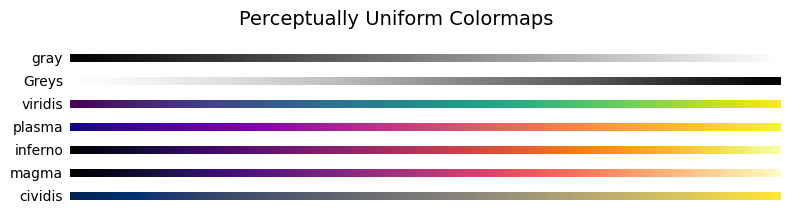

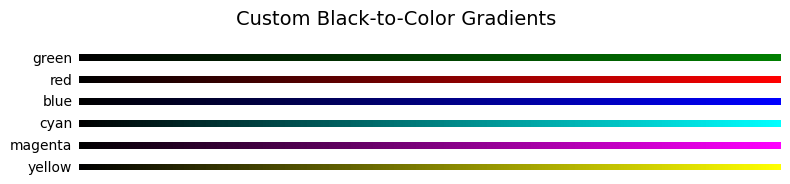


For a full list of matplotlib colormaps, visit:
https://matplotlib.org/stable/tutorials/colors/colormaps.html


In [92]:
def plot_colormaps(cmap_list, title):
    """Plot a set of colormaps as gradients."""
    gradient = np.linspace(0, 1, 256)
    gradient = np.vstack((gradient, gradient))

    nrows = len(cmap_list)
    fig, axes = plt.subplots(nrows=nrows, figsize=(8, 0.3 * nrows))
    fig.suptitle(title, fontsize=14, y=0.98)

    if nrows == 1:
        axes = [axes]

    for ax, cmap_name in zip(axes, cmap_list):
        ax.imshow(gradient, aspect="auto", cmap=get_colormap(cmap_name))
        ax.text(
            -0.01,
            0.5,
            cmap_name,
            va="center",
            ha="right",
            fontsize=10,
            transform=ax.transAxes,
        )
        ax.set_axis_off()

    plt.tight_layout()
    return fig


# Common colormaps for microscopy
print("Common colormaps for microscopy:\n")

fig1 = plot_colormaps(
    ["gray", "Greys", "viridis", "plasma", "inferno", "magma", "cividis"],
    "Perceptually Uniform Colormaps",
)
plt.show()

fig2 = plot_colormaps(
    ["green", "red", "blue", "cyan", "magenta", "yellow"],
    "Custom Black-to-Color Gradients",
)
plt.show()

print("\nFor a full list of matplotlib colormaps, visit:")
print("https://matplotlib.org/stable/tutorials/colors/colormaps.html")